# 25CSAI01I – Introduction to Data Science
## COVID-19 Case Surveillance Public Use Data

| Name | ID | Email |
|---|---|---|
| Mohamed Mahmoud | 249214 | mohamed249214@bue.edu.eg |
| Mohamed Yasser | 229267 | mohamed229267@bue.edu.eg |
| Mohamed Hesham | 247331 | mohamed247331@bue.edu.eg |
| Aly Mikaty | 245479 | aly245479@bue.edu.eg |


---
# Data Preparation


## Importing Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")


## Step 1 – Load the Dataset




In [2]:
df = pd.read_excel("DataSet.xlsx")

## Step 2 – Initial Inspection


Before doing anything else, we took a quick look to check rows, columns types, and some statistics. Just to understand what we are working on.


In [3]:
df.head()

,cdc_case_earliest_dt,cdc_report_dt,pos_spec_dt,onset_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn
0,2020-03-22,2021-01-16,2020-03-24,2020-03-22,Laboratory-confirmed case,Male,40 - 49 Years,Unknown,Yes,No,No,Yes
1,2020-12-29,2021-12-06,2021-01-07,2020-12-29,Laboratory-confirmed case,Female,60 - 69 Years,Unknown,No,No,No,No
2,2020-05-04,2021-12-06,2020-05-07,2020-05-04,Laboratory-confirmed case,Male,40 - 49 Years,Unknown,No,No,No,No
3,2020-04-07,2021-01-20,2020-04-10,2020-04-07,Laboratory-confirmed case,Male,50 - 59 Years,Unknown,No,No,No,Yes
4,2020-12-02,2021-12-06,2020-12-07,2020-12-02,Laboratory-confirmed case,Female,60 - 69 Years,Unknown,No,No,No,Yes


In [4]:
df.dtypes

cdc_case_earliest_dt       datetime64[ns]
cdc_report_dt              datetime64[ns]
pos_spec_dt                datetime64[ns]
onset_dt                   datetime64[ns]
current_status                     object
sex                                object
age_group                          object
race_ethnicity_combined            object
hosp_yn                            object
icu_yn                             object
death_yn                           object
medcond_yn                         object
dtype: object

In [5]:
df.describe(include='all')

,cdc_case_earliest_dt,cdc_report_dt,pos_spec_dt,onset_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn
count,2499,2499,1972,2299,2499,2499,2499,2499,2499,2499,2499,2499
unique,NaN,NaN,NaN,NaN,2,2,4,1,2,2,2,2
top,NaN,NaN,NaN,NaN,Laboratory-confirmed case,Female,50 - 59 Years,Unknown,No,No,No,Yes
freq,NaN,NaN,NaN,NaN,2319,1281,910,2499,1969,2305,2241,1365
mean,2020-08-10 11:38:58.055222272,2021-07-31 01:09:43.433373184,2020-07-16 22:30:10.953347072,2020-08-14 17:35:24.923880192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2020-03-01 00:00:00,2021-01-02 00:00:00,2020-03-11 00:00:00,2020-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2020-04-15 00:00:00,2021-01-20 00:00:00,2020-04-11 18:00:00,2020-04-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2020-08-19 00:00:00,2021-12-06 00:00:00,2020-06-25 00:00:00,2020-09-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2020-12-04 00:00:00,2021-12-06 00:00:00,2020-10-26 00:00:00,2020-12-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2020-12-31 00:00:00,2021-12-06 00:00:00,2021-11-05 00:00:00,2020-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 – Handle Missing Values

To hande missing data we treat Unkowns as missing in categorical columns and NaNs missing in date columns.


In [6]:
print(df.isnull().sum())

cat_cols = ['sex', 'age_group', 'race_ethnicity_combined',
            'hosp_yn', 'icu_yn', 'death_yn', 'medcond_yn', 'current_status']
for col in cat_cols:
    count = (df[col] == 'Unknown').sum()
    print(f"{col}: {count} Unknowns")

cdc_case_earliest_dt         0
cdc_report_dt                0
pos_spec_dt                527
onset_dt                   200
current_status               0
sex                          0
age_group                    0
race_ethnicity_combined      0
hosp_yn                      0
icu_yn                       0
death_yn                     0
medcond_yn                   0
dtype: int64
sex: 0 Unknowns
age_group: 0 Unknowns
race_ethnicity_combined: 2499 Unknowns
hosp_yn: 0 Unknowns
icu_yn: 0 Unknowns
death_yn: 0 Unknowns
medcond_yn: 0 Unknowns
current_status: 0 Unknowns


In [7]:
df.drop(columns=['race_ethnicity_combined'], inplace=True)

before = len(df)
df.dropna(subset=['pos_spec_dt'], inplace=True)
after = len(df)
print(f"Dropped {before - after} rows with missing 'pos_spec_dt'. Rows remaining: {after}")

Dropped 527 rows with missing 'pos_spec_dt'. Rows remaining: 1972


## Step 4 – Remove Duplicate Rows



In [8]:
print(f"Duplicates before: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Duplicates after: {df.duplicated().sum()}")

Duplicates before: 62
Duplicates after: 0


## Step 5 – Fix Column Names

We noticed that column "cdc_case_earliest_dt" had an extra space at the end of it, so we renamed it to remove the extra space.


In [9]:
df.rename(columns={'cdc_case_earliest_dt ': 'cdc_case_earliest_dt'}, inplace=True)

## Step 6 – Standardize Text Values

We strandardize values have inconsistent spacing or capitalization like "Yes " and "yes".


In [10]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()


## Step 7 – Drop Unnecessary Columns

We looked at all the columns and removed the ones that weren't needed for any of our research questions. We found that "cdc_report_dt" is just an adminstrative date that will not help with our analysis, so we decided to remove it.


In [11]:
df.drop(columns=['cdc_report_dt'], inplace=True)

## Step 8 – Encode Categorical Columns

To be able to do math on categorical data like calculating rates, we converted text values into numbers:
- Yes/No columns → Yes = 1, No = 0, Unknown = NaN
- Sex column → Female = 0, Male = 1
- Age group → Ordered numbers from 0 (youngest) to 3 (oldest)


In [12]:
yn_cols = ['hosp_yn', 'icu_yn', 'death_yn', 'medcond_yn']

for col in yn_cols:
    df[col + '_enc'] = df[col].replace({'Yes': 1, 'No': 0})


In [13]:
df['sex_enc'] = df['sex'].replace({'Female': 0, 'Male': 1})


In [14]:
age_order = {
    '40 - 49 Years': 0,
    '50 - 59 Years': 1,
    '60 - 69 Years': 2,
    '70 - 79 Years': 3
}
df['age_group_enc'] = df['age_group'].replace(age_order)


## Step 9 – Aggregate the Data

We grouped the data and calculated summary statistics for each group. These aggregated tables are what we'll use to answer our research questions.

In [15]:
age_agg = df.groupby('age_group')['death_yn_enc'].agg(['count', 'sum']).reset_index()
age_agg.rename(columns={'count': 'total_cases', 'sum': 'total_deaths'}, inplace=True)
age_agg['death_rate_%'] = (age_agg['total_deaths'] / age_agg['total_cases'] * 100).round(2)
age_order_list = ['40 - 49 Years', '50 - 59 Years', '60 - 69 Years', '70 - 79 Years']
age_agg = age_agg.set_index('age_group').reindex(age_order_list).reset_index()
age_agg


,age_group,total_cases,total_deaths,death_rate_%
0,40 - 49 Years,254,10,3.94
1,50 - 59 Years,690,44,6.38
2,60 - 69 Years,578,70,12.11
3,70 - 79 Years,388,130,33.51


In [16]:
gender_agg = df.groupby('sex')['death_yn_enc'].agg(['count', 'sum']).reset_index()
gender_agg.rename(columns={'count': 'total_cases', 'sum': 'deaths'}, inplace=True)
gender_agg['hospitalizations'] = df.groupby('sex')['hosp_yn_enc'].sum().values
gender_agg['icu_admissions'] = df.groupby('sex')['icu_yn_enc'].sum().values
gender_agg['death_rate_%'] = (gender_agg['deaths'] / gender_agg['total_cases'] * 100).round(2)
gender_agg['hosp_rate_%'] = (gender_agg['hospitalizations'] / gender_agg['total_cases'] * 100).round(2)
gender_agg['icu_rate_%'] = (gender_agg['icu_admissions'] / gender_agg['total_cases'] * 100).round(2)
gender_agg


,sex,total_cases,deaths,hospitalizations,icu_admissions,death_rate_%,hosp_rate_%,icu_rate_%
0,Female,966,200,329,128,20.70,34.06,13.25
1,Male,944,54,159,58,5.72,16.84,6.14


In [17]:
icu_agg = df.groupby('icu_yn')['death_yn_enc'].agg(['count', 'sum']).reset_index()
icu_agg.rename(columns={'count': 'total_cases', 'sum': 'total_deaths'}, inplace=True)
icu_agg['death_rate_%'] = (icu_agg['total_deaths'] / icu_agg['total_cases'] * 100).round(2)
icu_agg


,icu_yn,total_cases,total_deaths,death_rate_%
0,No,1724,118,6.84
1,Yes,186,136,73.12


In [18]:
age_agg

,age_group,total_cases,total_deaths,death_rate_%
0,40 - 49 Years,254,10,3.94
1,50 - 59 Years,690,44,6.38
2,60 - 69 Years,578,70,12.11
3,70 - 79 Years,388,130,33.51


In [19]:
hosp_agg = df.groupby('hosp_yn')['death_yn_enc'].agg(['count', 'sum']).reset_index()
hosp_agg.rename(columns={'count': 'total_cases', 'sum': 'total_deaths'}, inplace=True)
hosp_agg['death_rate_%'] = (hosp_agg['total_deaths'] / hosp_agg['total_cases'] * 100).round(2)
hosp_agg


,hosp_yn,total_cases,total_deaths,death_rate_%
0,No,1422,52,3.66
1,Yes,488,202,41.39


In [20]:
medcond_agg = df.groupby('medcond_yn')['death_yn_enc'].agg(['count', 'sum']).reset_index()
medcond_agg.rename(columns={'count': 'total_cases', 'sum': 'total_deaths'}, inplace=True)
medcond_agg['death_rate_%'] = (medcond_agg['total_deaths'] / medcond_agg['total_cases'] * 100).round(2)
medcond_agg


,medcond_yn,total_cases,total_deaths,death_rate_%
0,No,854,26,3.04
1,Yes,1056,228,21.59


In [21]:
df['year_month'] = df['cdc_case_earliest_dt'].dt.strftime('%Y-%m')
time_agg = df.groupby('year_month')['death_yn_enc'].agg(['count', 'sum']).reset_index()
time_agg.rename(columns={'count': 'total_cases', 'sum': 'total_deaths'}, inplace=True)
time_agg['total_hosp'] = df.groupby('year_month')['hosp_yn_enc'].sum().values
time_agg['death_rate_%'] = (time_agg['total_deaths'] / time_agg['total_cases'] * 100).round(2)
time_agg['hosp_rate_%'] = (time_agg['total_hosp'] / time_agg['total_cases'] * 100).round(2)
time_agg.head(10)


,year_month,total_cases,total_deaths,total_hosp,death_rate_%,hosp_rate_%
0,2020-03,371,40,122,10.78,32.88
1,2020-04,385,73,120,18.96,31.17
2,2020-05,157,32,53,20.38,33.76
3,2020-06,102,9,22,8.82,21.57
4,2020-07,110,10,18,9.09,16.36
5,2020-08,101,7,11,6.93,10.89
6,2020-09,108,5,14,4.63,12.96
7,2020-10,171,16,30,9.36,17.54
8,2020-11,207,38,52,18.36,25.12
9,2020-12,198,24,46,12.12,23.23


In [22]:
print(f"Shape: {df.shape}")
df.head()

Shape: (1910, 17)


,cdc_case_earliest_dt,pos_spec_dt,onset_dt,current_status,sex,age_group,hosp_yn,icu_yn,death_yn,medcond_yn,hosp_yn_enc,icu_yn_enc,death_yn_enc,medcond_yn_enc,sex_enc,age_group_enc,year_month
0,2020-03-22,2020-03-24,2020-03-22,Laboratory-confirmed case,Male,40 - 49 Years,Yes,No,No,Yes,1,0,0,1,1,0,2020-03
1,2020-12-29,2021-01-07,2020-12-29,Laboratory-confirmed case,Female,60 - 69 Years,No,No,No,No,0,0,0,0,0,2,2020-12
2,2020-05-04,2020-05-07,2020-05-04,Laboratory-confirmed case,Male,40 - 49 Years,No,No,No,No,0,0,0,0,1,0,2020-05
3,2020-04-07,2020-04-10,2020-04-07,Laboratory-confirmed case,Male,50 - 59 Years,No,No,No,Yes,0,0,0,1,1,1,2020-04
4,2020-12-02,2020-12-07,2020-12-02,Laboratory-confirmed case,Female,60 - 69 Years,No,No,No,Yes,0,0,0,1,0,2,2020-12


---
# Data Visualization and Interpretation


---
## Mohamed Mahmoud Rizk – Questions 1, 2, 3


### Question 1: Does the risk of dying from COVID-19 increase with age?

We wanted to see if older patients were more likely to die from COVID-19. The chart below shows the death rate for each age group.


We used the age group summary table to calculate the death rate for each group and plotted them as a bar chart.


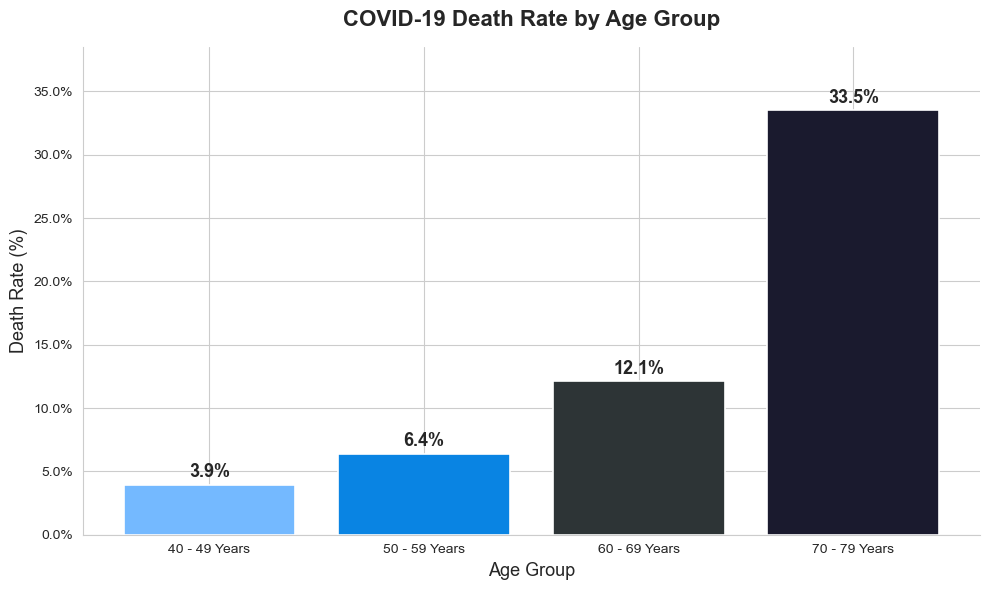

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#74b9ff', '#0984e3', '#2d3436', '#1a1a2e']
bars = ax.bar(age_agg['age_group'], age_agg['death_rate_%'], color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, age_agg['death_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title('COVID-19 Death Rate by Age Group', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=13)
ax.set_ylabel('Death Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, age_agg['death_rate_%'].max() + 5)
sns.despine()
plt.tight_layout()
plt.savefig('Q1_death_rate_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

The chart makes it pretty clear, the older the age group, the higher the death rate. Patients in the 70–79 range had by far the highest mortality, while those aged 40–49 had the lowest. This makes sense given that older people generally have weaker immune systems and more underlying health issues.


### Question 2: Do COVID-19 outcomes differ between males and females?

We compared death rate, hospitalization rate, and ICU admission rate between male and female patients to see if gender played any role.


We plotted the three outcome rates side by side for both genders using a grouped bar chart.


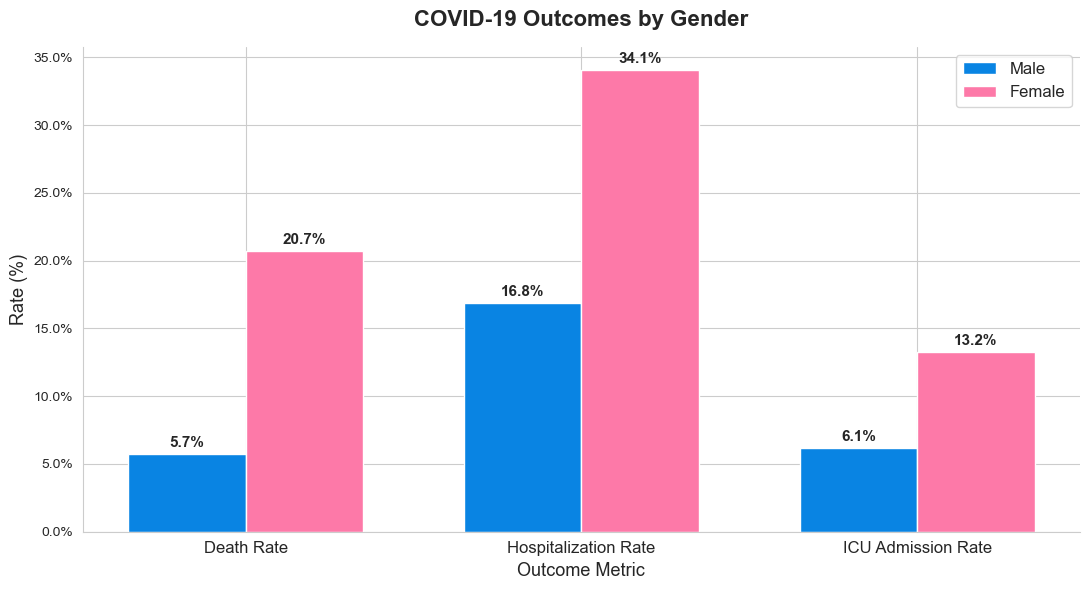

In [24]:
metrics = ['death_rate_%', 'hosp_rate_%', 'icu_rate_%']
metric_labels = ['Death Rate', 'Hospitalization Rate', 'ICU Admission Rate']

male_vals = gender_agg[gender_agg['sex'] == 'Male'][metrics].iloc[0]
female_vals = gender_agg[gender_agg['sex'] == 'Female'][metrics].iloc[0]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_m = ax.bar(x - width/2, male_vals, width, label='Male', color='#0984e3', edgecolor='white')
bars_f = ax.bar(x + width/2, female_vals, width, label='Female', color='#fd79a8', edgecolor='white')

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('COVID-19 Outcomes by Gender', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Outcome Metric', fontsize=13)
ax.set_ylabel('Rate (%)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('Q2_outcomes_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()


Females show higher rates across all three outcomes like death, hospitalization, and ICU admission. This suggests that in this dataset, females experienced more severe COVID-19 outcomes compared to males.

### Question 3: Is ICU admission a good predictor of death?

We looked at whether patients who ended up in the ICU were more likely to die, which could make ICU admission a useful early warning signal.


We compared death rates between ICU-admitted and non-ICU patients using the ICU aggregation table.


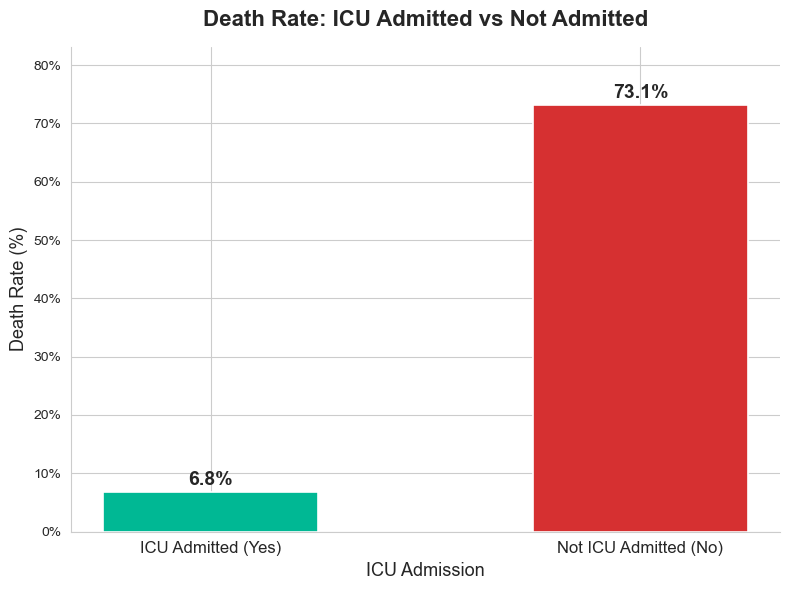

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

icu_plot = icu_agg[icu_agg['icu_yn'].isin(['Yes', 'No'])].copy()
colors_icu = ['#00b894', '#d63031']

bars = ax.bar(icu_plot['icu_yn'], icu_plot['death_rate_%'],
              color=colors_icu, edgecolor='white', linewidth=1.2, width=0.5)

for bar, val in zip(bars, icu_plot['death_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=14)

ax.set_title('Death Rate: ICU Admitted vs Not Admitted', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('ICU Admission', fontsize=13)
ax.set_ylabel('Death Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(['ICU Admitted (Yes)', 'Not ICU Admitted (No)'], fontsize=12)
ax.set_ylim(0, icu_plot['death_rate_%'].max() + 10)
sns.despine()
plt.tight_layout()
plt.savefig('Q3_death_rate_icu.png', dpi=150, bbox_inches='tight')
plt.show()

Patients who were not admitted to the ICU show a much higher recorded death rate than those who were admitted. This result is unexpected and likely indicates issues with missing or misclassified ICU data rather than a true clinical relationship.

---
## Mohamed Yasser – Questions 4, 5, 6


### Question 4: Are hospitalized patients more likely to die from COVID-19?

We checked whether being admitted to a hospital was associated with a higher chance of dying.


We used the hospitalization summary table to compare death rates between hospitalized and non-hospitalized patients.


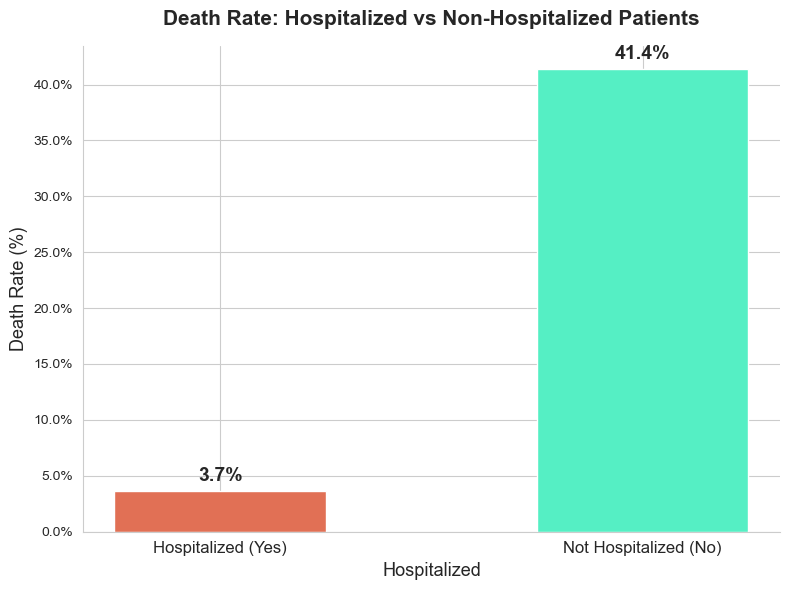

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
hosp_plot = hosp_agg[hosp_agg['hosp_yn'].isin(['Yes', 'No'])]
colors_h = ['#e17055', '#55efc4']
bars = ax.bar(hosp_plot['hosp_yn'], hosp_plot['death_rate_%'],
              color=colors_h, edgecolor='white', width=0.5)
for bar, val in zip(bars, hosp_plot['death_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.set_title('Death Rate: Hospitalized vs Non-Hospitalized Patients', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Hospitalized', fontsize=13)
ax.set_ylabel('Death Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(['Hospitalized (Yes)', 'Not Hospitalized (No)'], fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('Q4_death_rate_hosp.png', dpi=150, bbox_inches='tight')
plt.show()

The chart shows that non-hospitalized patients have a higher observed death rate (41.4%) compared to hospitalized patients (3.7%). This unexpected finding suggests potential data limitations or classification issues, and therefore no causal conclusion about hospitalization reducing mortality can be made.

### Question 5: Did the COVID-19 death rate change over time?

We tracked how the monthly death rate shifted throughout the pandemic to see if things got better or worse over time.


We grouped the data by month, calculated the death rate for each month, and plotted it as a line chart.


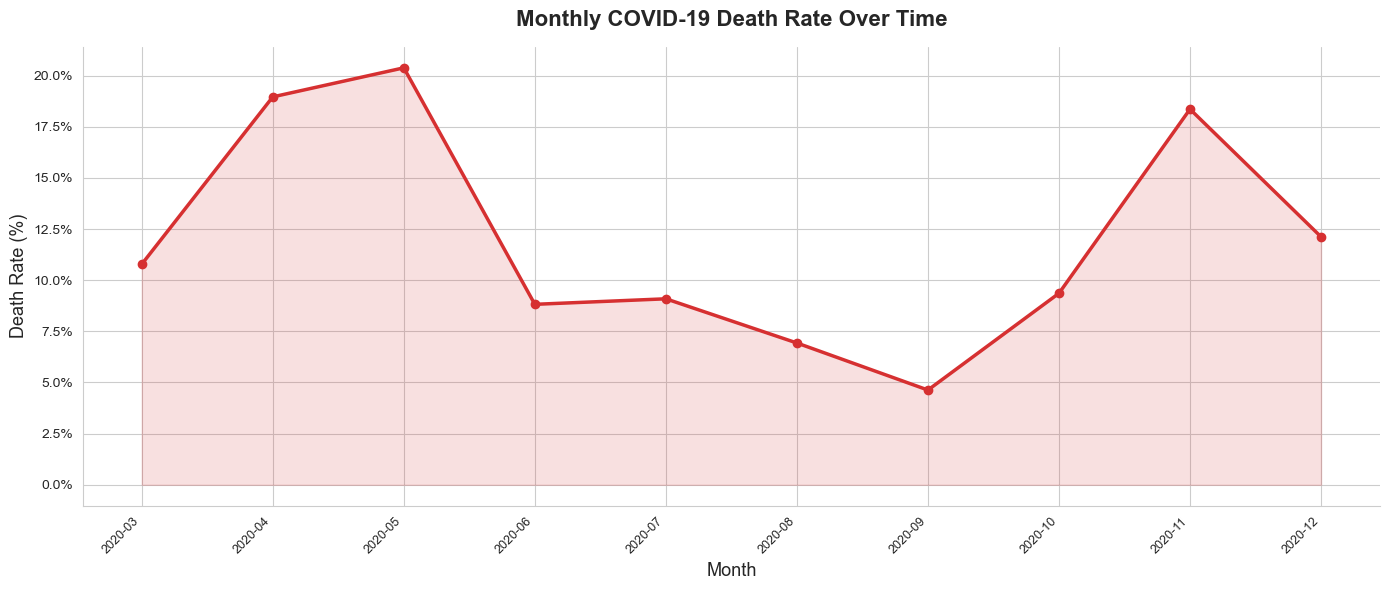

In [27]:
time_plot = time_agg[time_agg['total_cases'] >= 5].copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time_plot['year_month'], time_plot['death_rate_%'],
        color='#d63031', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(range(len(time_plot)), time_plot['death_rate_%'], alpha=0.15, color='#d63031')
ax.set_title('Monthly COVID-19 Death Rate Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Death Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45, ha='right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('Q5_death_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


The death rate changed a lot over time, with high peaks in April and May and another rise in November. It generally went down after the first peak, but not steadily. This is likely due to better treatment, more testing, and improved experience in handling COVID-19 cases.

### Question 6: Which Age group had the most COVID-19 cases?

We wanted to find which Age group had the most COVID-19 cases.

This counts the Covid-19 cases per Age group.

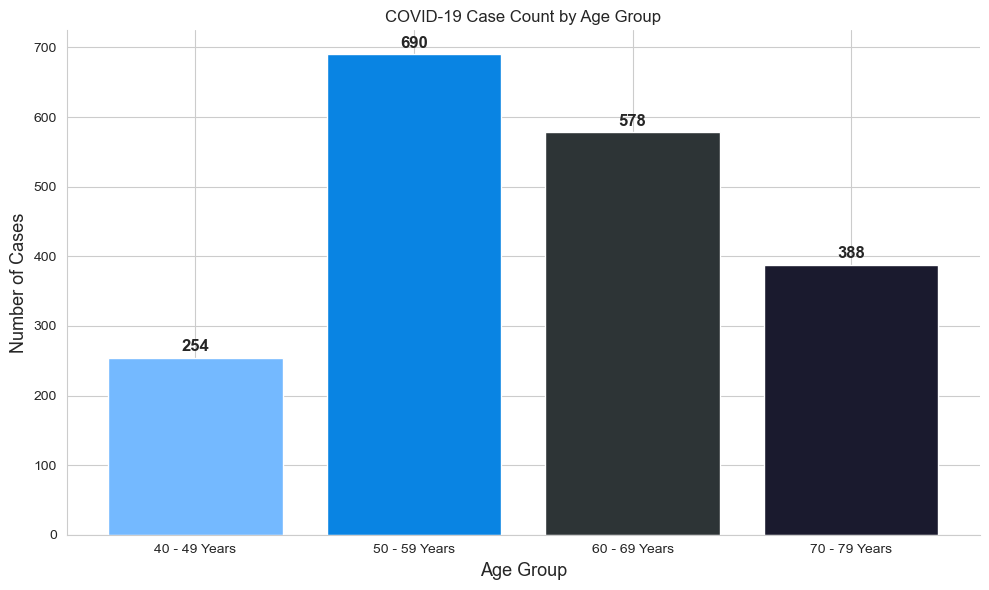

In [28]:
cross_tab = pd.crosstab(df['icu_yn'], df['death_yn'])
cross_tab = cross_tab.loc[['Yes', 'No'], ['Yes', 'No']]

fig, ax = plt.subplots(figsize=(10, 6))
case_counts = df['age_group'].value_counts().reindex(age_order_list)
colors_demo = ['#74b9ff', '#0984e3', '#2d3436', '#1a1a2e']
bars = ax.bar(case_counts.index, case_counts.values, color=colors_demo, edgecolor='white')
for bar, val in zip(bars, case_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(val):,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('COVID-19 Case Count by Age Group')
ax.set_xlabel('Age Group', fontsize=13)
ax.set_ylabel('Number of Cases', fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig('Q6_cases_by_age_proxy.png', dpi=150, bbox_inches='tight')
plt.show()


The 50–59 age group has the highest number of cases, followed by 60–69, while 40–49 has the lowest among these groups.

---
## Mohamed Hesham – Questions 7, 8, 9


### Question 7: Did having pre-existing medical conditions affect mortality?

We wanted to find out if patients with underlying health conditions (like diabetes or heart disease) were more likely to die from COVID-19.


We compared death rates between patients who had pre-existing conditions and those who didn't, using the medical condition summary table.


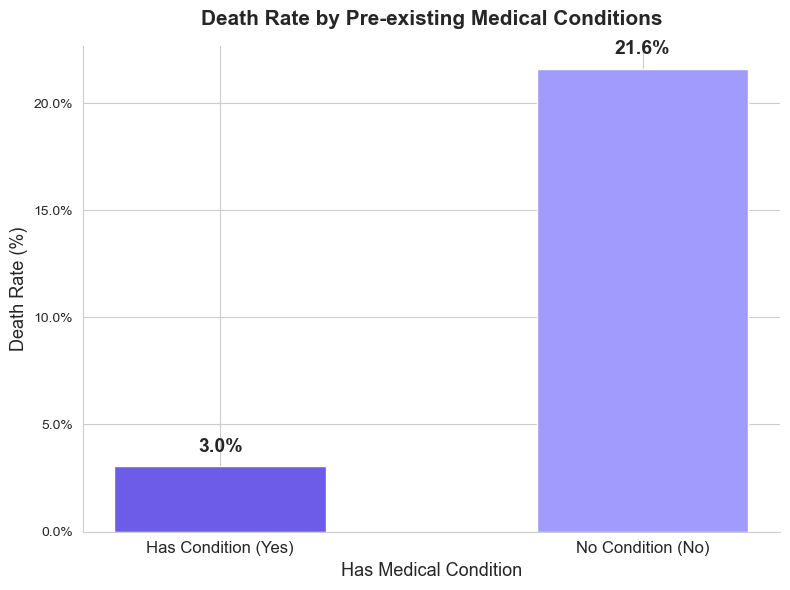

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
medcond_plot = medcond_agg[medcond_agg['medcond_yn'].isin(['Yes', 'No'])]
colors_m = ['#6c5ce7', '#a29bfe']
bars = ax.bar(medcond_plot['medcond_yn'], medcond_plot['death_rate_%'],
              color=colors_m, edgecolor='white', width=0.5)
for bar, val in zip(bars, medcond_plot['death_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.set_title('Death Rate by Pre-existing Medical Conditions', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Has Medical Condition', fontsize=13)
ax.set_ylabel('Death Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(['Has Condition (Yes)', 'No Condition (No)'], fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('Q7_death_rate_medcond.png', dpi=150, bbox_inches='tight')
plt.show()

The chart indicates that patients without pre-existing conditions have a higher observed death rate than those with conditions. This unexpected result suggests potential issues in the data or variable classification, and therefore should be interpreted with caution rather than as a true clinical finding.

### Question 8: Did hospitalization rates go up or down throughout the pandemic?

We tracked monthly hospitalization rates to see how hospital burden changed over the course of the pandemic.


We calculated monthly hospitalization rates from the time aggregation table and plotted them as a line chart.


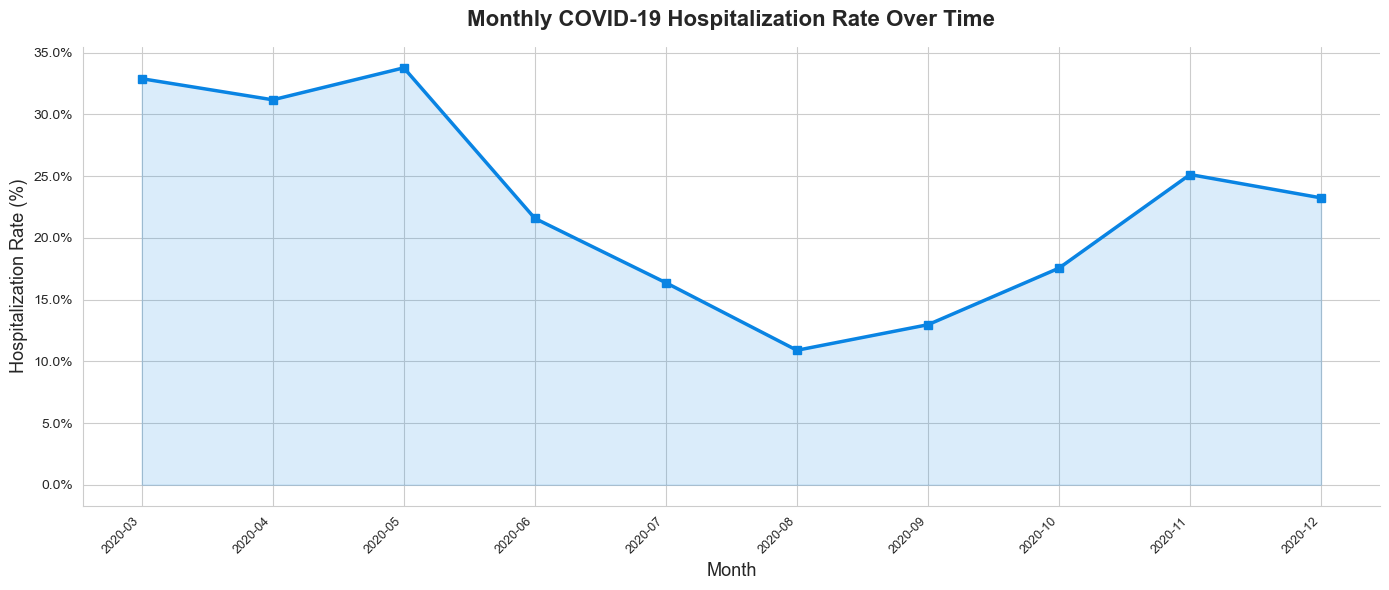

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time_plot['year_month'], time_plot['hosp_rate_%'],
        color='#0984e3', linewidth=2.5, marker='s', markersize=6)
ax.fill_between(range(len(time_plot)), time_plot['hosp_rate_%'], alpha=0.15, color='#0984e3')
ax.set_title('Monthly COVID-19 Hospitalization Rate Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Hospitalization Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45, ha='right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('Q8_hosp_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


The hospitalization rate went up and down in waves rather than following a straight line. There were clear surges during peak periods, but things stabilized at other times. This pattern shows that hospital capacity planning needs to account for these waves, it's not a steady increase but more of a series of peaks and valleys.


### Question 9: Can ICU admission indicate how severe a COVID-19 case is?

We explored whether ICU admission could be used as a marker for severe COVID-19 outcomes.


We compared mortality outcomes between ICU-admitted and non-ICU patients to see how strongly ICU admission relates to death.


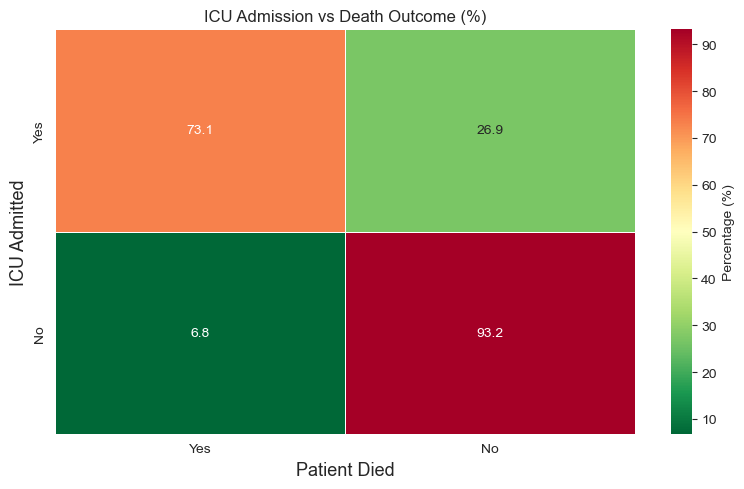

In [31]:
cross_tab = pd.crosstab(df['icu_yn'], df['death_yn'])
cross_tab = cross_tab.loc[['Yes', 'No'], ['Yes', 'No']]

cross_pct = cross_tab.copy()
cross_pct['Yes'] = (cross_tab['Yes'] / (cross_tab['Yes'] + cross_tab['No'])) * 100
cross_pct['No'] = (cross_tab['No'] / (cross_tab['Yes'] + cross_tab['No'])) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Percentage (%)'})
ax.set_title('ICU Admission vs Death Outcome (%)')
ax.set_xlabel('Patient Died', fontsize=13)
ax.set_ylabel('ICU Admitted', fontsize=13)
plt.tight_layout()
plt.savefig('Q9_icu_death_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


The chart demonstrates that ICU-admitted patients have a significantly higher observed death rate than non-ICU patients. This is expected, as ICU admission is generally reserved for critically ill patients. Therefore, ICU admission serves as a strong indicator of disease severity rather than a causal factor in mortality.

---
## Aly Mikaty – Questions 10,11,12

### Question 10: Does the risk of hospitalization increase with age?

We already looked at how age affects death rate (Q1), but we wanted to know whether older patients were also more likely to be hospitalized in the first place.

We used the age group column to calculate the hospitalization rate for each group and plotted them as a bar chart.

In [32]:
age_hosp = df.groupby('age_group')['hosp_yn_enc'].agg(['count', 'sum']).reset_index()
age_hosp.rename(columns={'count': 'total_cases', 'sum': 'total_hosp'}, inplace=True)
age_hosp['hosp_rate_%'] = (age_hosp['total_hosp'] / age_hosp['total_cases'] * 100).round(2)
age_hosp = age_hosp.set_index('age_group').reindex(age_order_list).reset_index()
age_hosp

,age_group,total_cases,total_hosp,hosp_rate_%
0,40 - 49 Years,254,25,9.84
1,50 - 59 Years,690,134,19.42
2,60 - 69 Years,578,143,24.74
3,70 - 79 Years,388,186,47.94


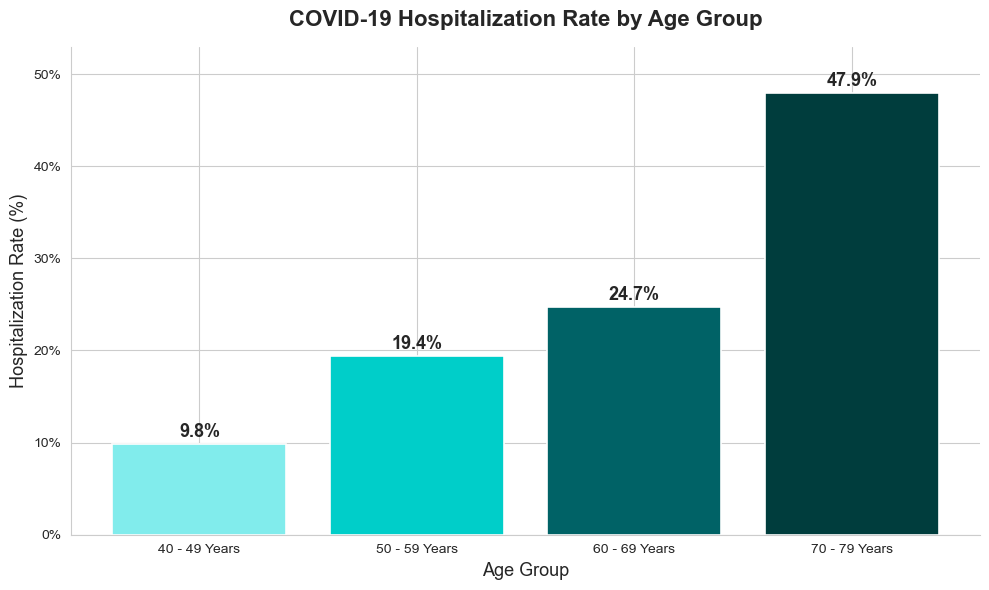

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#81ecec', '#00cec9', '#006266', '#003d3d']
bars = ax.bar(age_hosp['age_group'], age_hosp['hosp_rate_%'],
              color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, age_hosp['hosp_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title('COVID-19 Hospitalization Rate by Age Group', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=13)
ax.set_ylabel('Hospitalization Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, age_hosp['hosp_rate_%'].max() + 5)
sns.despine()
plt.tight_layout()
plt.savefig('Q10_hosp_rate_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

The chart clearly shows that hospitalization risk rises with age, just like death rate does. The 70–79 group has a hospitalization rate of nearly 48%, almost five times higher than the 40–49 group. This confirms that age is a consistent risk factor across all COVID-19 severity indicators, not just mortality.

### Question 11: How did the ICU admission rate change over the course of the pandemic?

We tracked how the monthly death rate and hospitalization rate changed over time in Q5 and Q8. Here we do the same for ICU admissions to see if the ICU burden followed the same wave pattern.

We grouped the data by month, calculated the ICU admission rate for each month, and plotted it as a line chart.

In [34]:
time_icu = df.groupby('year_month')['icu_yn_enc'].agg(['count', 'sum']).reset_index()
time_icu.rename(columns={'count': 'total_cases', 'sum': 'total_icu'}, inplace=True)
time_icu['icu_rate_%'] = (time_icu['total_icu'] / time_icu['total_cases'] * 100).round(2)
time_icu = time_icu[time_icu['total_cases'] >= 5].copy()
time_icu.head(12)

,year_month,total_cases,total_icu,icu_rate_%
0,2020-03,371,40,10.78
1,2020-04,385,52,13.51
2,2020-05,157,22,14.01
3,2020-06,102,4,3.92
4,2020-07,110,8,7.27
5,2020-08,101,5,4.95
6,2020-09,108,3,2.78
7,2020-10,171,14,8.19
8,2020-11,207,22,10.63
9,2020-12,198,16,8.08


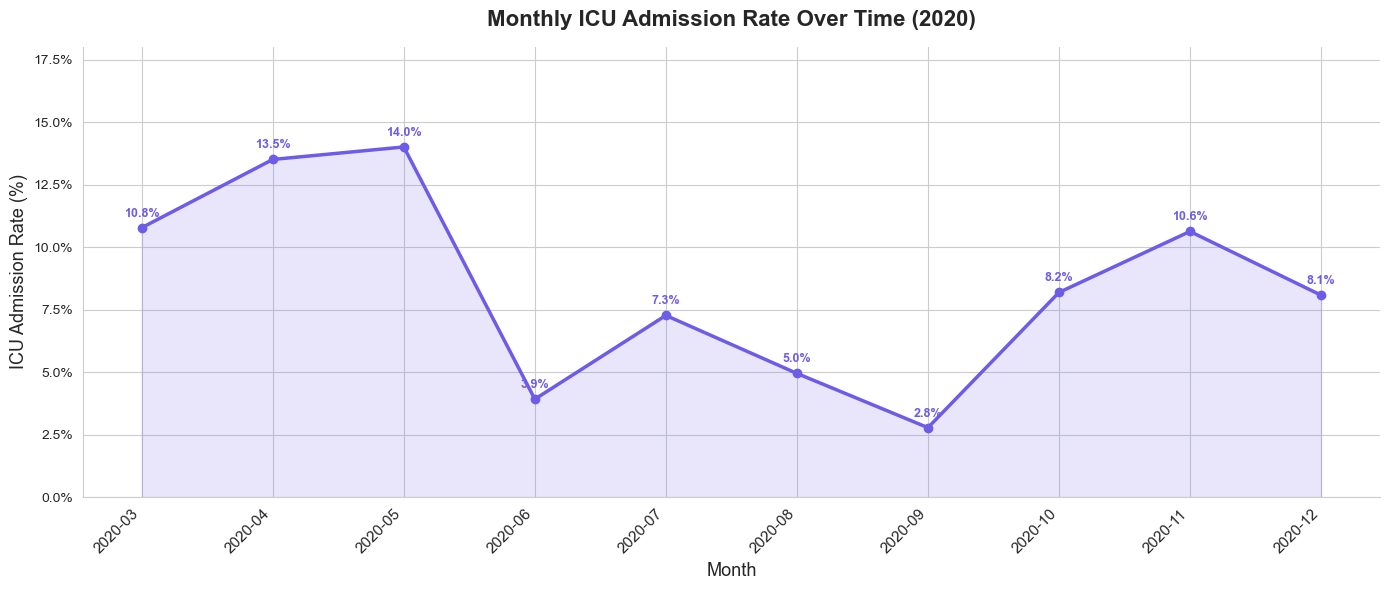

In [35]:
time_icu_plot = time_icu.reset_index(drop=True)
x_idx = range(len(time_icu_plot))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(list(x_idx), time_icu_plot['icu_rate_%'].tolist(),
        color='#6c5ce7', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(list(x_idx), time_icu_plot['icu_rate_%'].tolist(),
                alpha=0.15, color='#6c5ce7')

for i, row in time_icu_plot.iterrows():
    ax.annotate(f"{row['icu_rate_%']:.1f}%",
                xy=(i, row['icu_rate_%']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#6c5ce7')

ax.set_title('Monthly ICU Admission Rate Over Time (2020)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('ICU Admission Rate (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(list(x_idx))
ax.set_xticklabels(time_icu_plot['year_month'].tolist(), rotation=45, ha='right', fontsize=11)
ax.set_ylim(0, time_icu_plot['icu_rate_%'].max() + 4)
sns.despine()
plt.tight_layout()
plt.savefig('Q11_icu_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

The ICU admission rate followed the same two-wave pattern as the death rate. It peaked at 14.0% in May 2020, dropped to its lowest point of 2.8% in September, then climbed back up to 10.6% in November before settling at 8.1% in December. This suggests the ICU burden closely tracks pandemic waves, and that the September lull reflects the summer drop in transmission seen across all other metrics.


### Question 12: Among hospitalized patients, does the need for ICU care increase with age?

Q10 showed us that older patients are more likely to be hospitalized. Here we go one step further and ask: of the patients who were already hospitalized, how many also needed ICU-level care? And does that fraction change with age?

We filtered to hospitalized patients only, then calculated the ICU escalation rate for each age group and plotted it as a bar chart.

In [36]:
hosp_only = df[df['hosp_yn'] == 'Yes'].copy()

icu_in_hosp = hosp_only.groupby('age_group')['icu_yn_enc'].agg(['count', 'sum']).reset_index()
icu_in_hosp.rename(columns={'count': 'total_hosp', 'sum': 'icu_count'}, inplace=True)
icu_in_hosp['icu_of_hosp_%'] = (icu_in_hosp['icu_count'] / icu_in_hosp['total_hosp'] * 100).round(2)
icu_in_hosp = icu_in_hosp.set_index('age_group').reindex(age_order_list).reset_index()
icu_in_hosp

,age_group,total_hosp,icu_count,icu_of_hosp_%
0,40 - 49 Years,25,7,28.00
1,50 - 59 Years,134,50,37.31
2,60 - 69 Years,143,55,38.46
3,70 - 79 Years,186,72,38.71


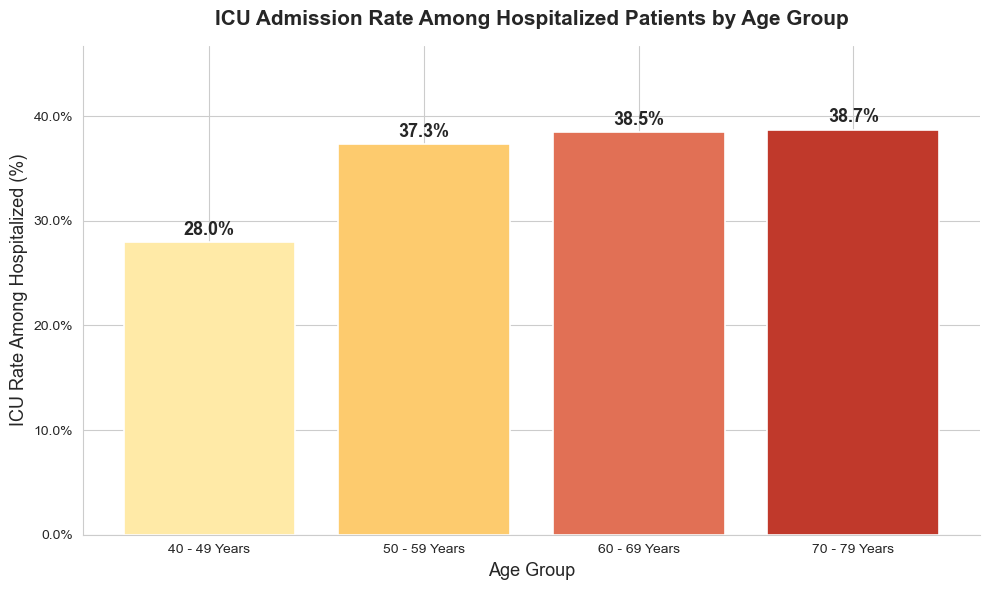

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#ffeaa7', '#fdcb6e', '#e17055', '#c0392b']
bars = ax.bar(icu_in_hosp['age_group'], icu_in_hosp['icu_of_hosp_%'],
              color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, icu_in_hosp['icu_of_hosp_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title('ICU Admission Rate Among Hospitalized Patients by Age Group',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=13)
ax.set_ylabel('ICU Rate Among Hospitalized (%)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, icu_in_hosp['icu_of_hosp_%'].max() + 8)
sns.despine()
plt.tight_layout()
plt.savefig('Q12_icu_among_hosp_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

The biggest jump in ICU escalation happens between the 40–49 group (28.0%) and the 50–59 group (37.1%). After that, the rate stays roughly flat at around 38–39% for the older cohorts. This means that once a patient is in their 50s or older, about 1 in 3 hospitalizations will escalate to ICU-level care, making age a key variable for ICU capacity planning even within the already-hospitalized population.

---